In [1]:
import matplotlib.pyplot as plt
import pandas as pd
from src import baseClasses, systemClasses, sensorClasses, muxClasses
import datetime
import numpy as np
from tqdm import tqdm
import pickle
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

In [2]:
dataset = baseClasses.Data()

In [3]:
mask = (
    ((dataset.data.index > datetime.datetime(2024, 4, 30)) & (dataset.data.index < datetime.datetime(2024, 5, 15))) |
    ((dataset.data.index > datetime.datetime(2024, 11, 20)) & (dataset.data.index < datetime.datetime(2024, 12, 10)))
)

dataset.data = dataset.data.loc[mask]
dataset.err = dataset.err.loc[mask]

In [4]:
tgrad = systemClasses.System(dataset=dataset, name="TGRAD")
apa = systemClasses.System(dataset=dataset, name="APA")
prm = systemClasses.System(dataset=dataset, name="PRM")
pipe = systemClasses.System(dataset=dataset, name="PIPE")
pp = systemClasses.System(dataset=dataset, name="PP")
hawai = systemClasses.System(dataset=dataset, name="HAWAI")

Initializing TGRAD Sensors:   0%|          | 0/48 [00:00<?, ?sensor/s]

Initializing PIPE Sensors: 100%|██████████| 12/12 [00:01<00:00,  9.90sensor/s]


ERROR: Channel (TE0120) not found


Initializing HAWAI Sensors: 100%|██████████| 24/24 [00:02<00:00, 10.70sensor/s]


In [5]:
tgrad.calibrate(calibName="SECOND_POFF_TGRAD_HAWAI_APA_CE_OFF_REC_OFF_HV_OFF_20241203_134500_20241203_141500")
apa.calibrate(calibName="SECOND_POFF_TGRAD_HAWAI_APA_CE_OFF_REC_OFF_HV_OFF_20241203_134500_20241203_141500")
prm.calibrate(calibName="FIRST_POFF_TGRAD_APA_PP_PRM_PIPE_CE_OFF_REC_OFF_HV_OFF_20240502_094500_20240502_100000")
pipe.calibrate(calibName="FIRST_POFF_TGRAD_APA_PP_PRM_PIPE_CE_OFF_REC_OFF_HV_OFF_20240502_094500_20240502_100000")
pp.calibrate(calibName="FIRST_POFF_TGRAD_APA_PP_PRM_PIPE_CE_OFF_REC_OFF_HV_OFF_20240502_094500_20240502_100000")
hawai.calibrate(calibName="SECOND_POFF_TGRAD_HAWAI_APA_CE_OFF_REC_OFF_HV_OFF_20241203_134500_20241203_141500")

Equalizing TGRAD Sensors: 100%|██████████| 48/48 [00:05<00:00,  8.86sensor/s]
Calibrating TGRAD Sensors - Calibration Name: SECOND_POFF_TGRAD_HAWAI_APA_CE_OFF_REC_OFF_HV_OFF_20241203_134500_20241203_141500: 100%|██████████| 48/48 [00:00<00:00, 72.71sensor/s]
Equalizing APA Sensors: 100%|██████████| 16/16 [00:01<00:00, 12.81sensor/s]
Calibrating APA Sensors - Calibration Name: SECOND_POFF_TGRAD_HAWAI_APA_CE_OFF_REC_OFF_HV_OFF_20241203_134500_20241203_141500: 100%|██████████| 16/16 [00:00<00:00, 95.95sensor/s]
Equalizing PRM Sensors: 100%|██████████| 6/6 [00:00<00:00,  8.71sensor/s]
Calibrating PRM Sensors - Calibration Name: FIRST_POFF_TGRAD_APA_PP_PRM_PIPE_CE_OFF_REC_OFF_HV_OFF_20240502_094500_20240502_100000: 100%|██████████| 6/6 [00:00<00:00, 55.04sensor/s]
Equalizing PIPE Sensors: 100%|██████████| 12/12 [00:01<00:00,  9.07sensor/s]


ERROR: Channel (TE0120) not found


Calibrating PIPE Sensors - Calibration Name: FIRST_POFF_TGRAD_APA_PP_PRM_PIPE_CE_OFF_REC_OFF_HV_OFF_20240502_094500_20240502_100000: 100%|██████████| 12/12 [00:00<00:00, 94.28sensor/s]
Equalizing PP Sensors: 100%|██████████| 2/2 [00:00<00:00,  9.23sensor/s]
Calibrating PP Sensors - Calibration Name: FIRST_POFF_TGRAD_APA_PP_PRM_PIPE_CE_OFF_REC_OFF_HV_OFF_20240502_094500_20240502_100000: 100%|██████████| 2/2 [00:00<00:00, 86.24sensor/s]
Equalizing HAWAI Sensors: 100%|██████████| 24/24 [00:02<00:00, 10.42sensor/s]
Calibrating HAWAI Sensors - Calibration Name: SECOND_POFF_TGRAD_HAWAI_APA_CE_OFF_REC_OFF_HV_OFF_20241203_134500_20241203_141500: 100%|██████████| 24/24 [00:00<00:00, 100.44sensor/s]


In [6]:
mux1 = muxClasses.MUX(dataset=dataset, boardNumber=1)
mux2 = muxClasses.MUX(dataset=dataset, boardNumber=2)
mux3 = muxClasses.MUX(dataset=dataset, boardNumber=3)
mux4 = muxClasses.MUX(dataset=dataset, boardNumber=4)

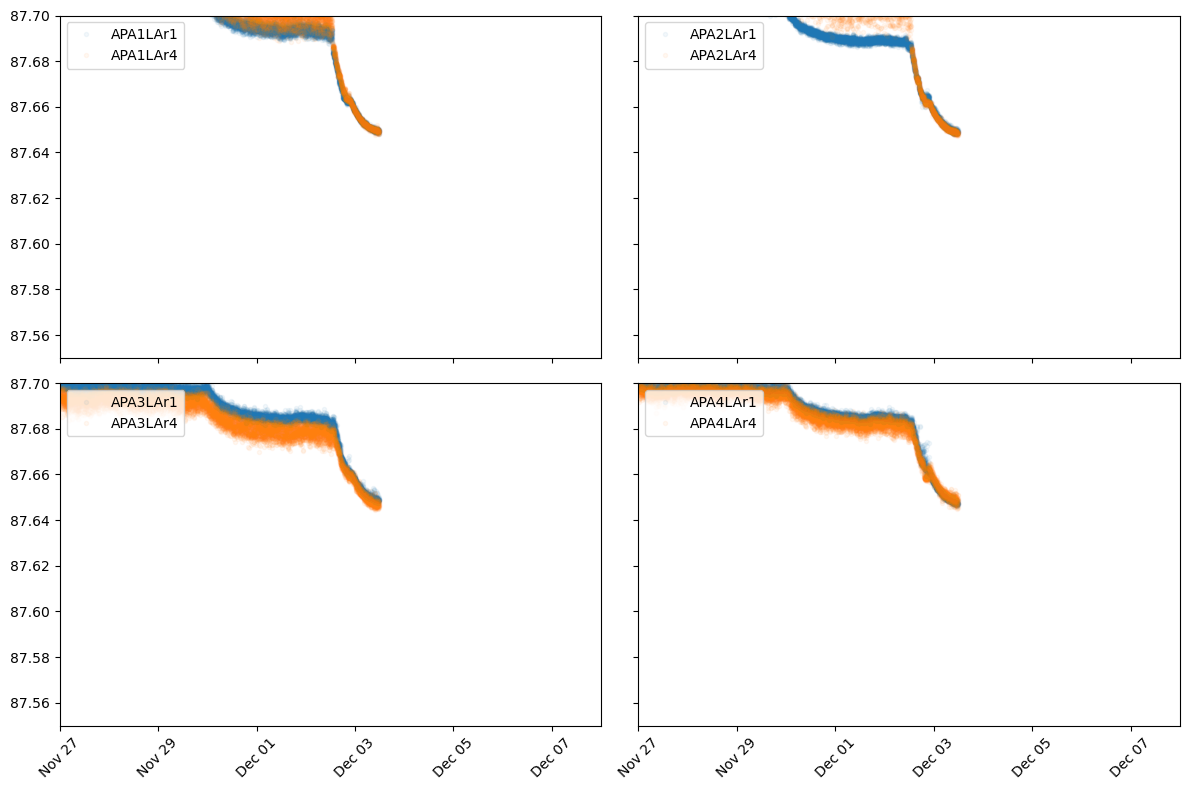

In [7]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import datetime

fig, axes = plt.subplots(ncols=2, nrows=2, figsize=(12, 8), sharex=True, sharey=True)
axes = axes.flatten()

date_format = mdates.DateFormatter("%b %d")  # Format dates as 'Nov 27'
start_date = datetime.datetime(2024, 11, 27, 0, 0, 0)
end_date = datetime.datetime(2024, 12, 8, 0, 0, 0)

ylim_low, ylim_high = 87.55, 87.7  # Common y-axis limits

sensor_map = {"APA1": 0, "APA2": 1, "APA3": 2, "APA4": 3}

for id, sensor in apa.sensors.items():
    if any(excluded in sensor.name for excluded in ["LAr3", "LAr2", "F"]):
        continue

    for apaName, ax_idx in sensor_map.items():
        if apaName in sensor.name:
            ax = axes[ax_idx]
            ax.plot(sensor.data, ".", label=sensor.name, alpha=.05)
            ax.set_ylim(ylim_low, ylim_high)
            ax.set_xlim(start_date, end_date)
            ax.xaxis.set_major_formatter(date_format)
            ax.tick_params(axis="x", rotation=45)
            ax.legend(loc="upper left")
            break  # Exit inner loop once matched

fig.tight_layout()  # Adjust layout to prevent overlap
plt.show()


<ErrorbarContainer object of 3 artists>

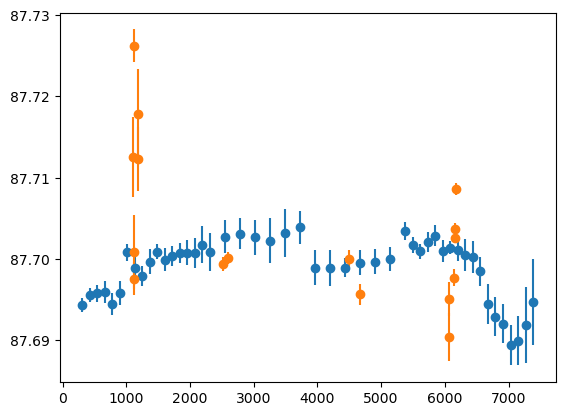

In [21]:
tgrad.makeProfiles(tini=datetime.datetime(2024, 11, 29, 12, 45, 0), tend=datetime.datetime(2024, 11, 29, 13, 0, 0))
apa.makeProfiles(tini=datetime.datetime(2024, 11, 29, 12, 45, 0), tend=datetime.datetime(2024, 11, 29, 13, 0, 0))
plt.errorbar(tgrad.profiles["Y"].values, tgrad.profiles["temp"].values, yerr=tgrad.profiles["err"].values, fmt='o', label="2024-05-10 00:31:00")
plt.errorbar(apa.profiles["Y"].values, apa.profiles["temp"].values, yerr=apa.profiles["err"].values, fmt='o', label="2024-05-10 00:31:00")

<ErrorbarContainer object of 3 artists>

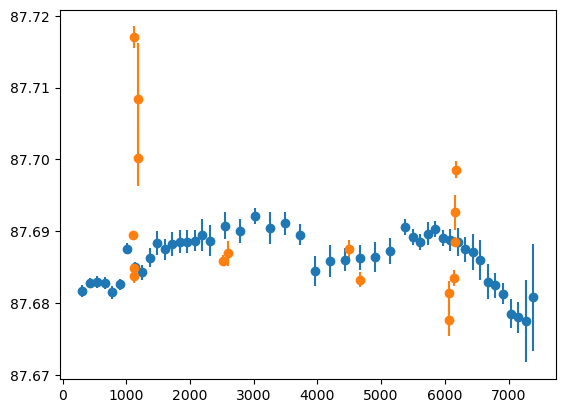

In [22]:
tgrad.makeProfiles(tini=datetime.datetime(2024, 12, 2, 5, 45, 0), tend=datetime.datetime(2024, 12, 2, 6, 0, 0))
apa.makeProfiles(tini=datetime.datetime(2024, 12, 2, 5, 45, 0), tend=datetime.datetime(2024, 12, 2, 6, 0, 0))
plt.errorbar(tgrad.profiles["Y"].values, tgrad.profiles["temp"].values, yerr=tgrad.profiles["err"].values, fmt='o', label="2024-05-10 00:31:00")
plt.errorbar(apa.profiles["Y"].values, apa.profiles["temp"].values, yerr=apa.profiles["err"].values, fmt='o', label="2024-05-10 00:31:00")

<ErrorbarContainer object of 3 artists>

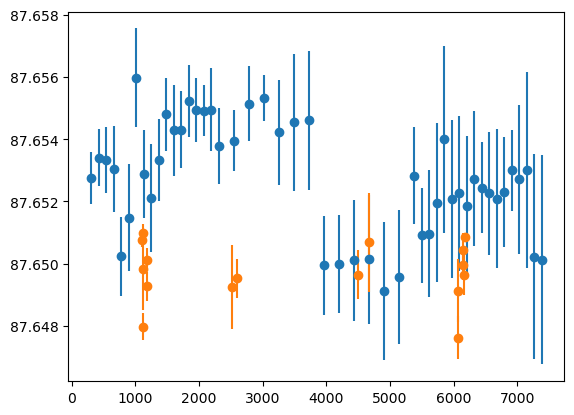

In [23]:
tgrad.makeProfiles(tini=datetime.datetime(2024, 12, 3, 8, 45, 0), tend=datetime.datetime(2024, 12, 3, 9, 0, 0))
apa.makeProfiles(tini=datetime.datetime(2024, 12, 3, 8, 45, 0), tend=datetime.datetime(2024, 12, 3, 9, 0, 0))
plt.errorbar(tgrad.profiles["Y"].values, tgrad.profiles["temp"].values, yerr=tgrad.profiles["err"].values, fmt='o', label="2024-05-10 00:31:00")
plt.errorbar(apa.profiles["Y"].values, apa.profiles["temp"].values, yerr=apa.profiles["err"].values, fmt='o', label="2024-05-10 00:31:00")

(20054.0, 20065.0)

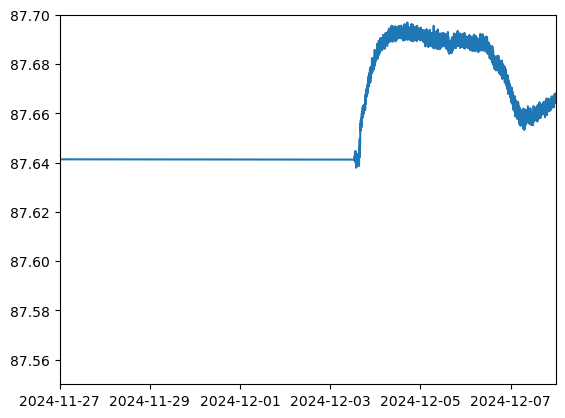

In [11]:
fig, ax = plt.subplots(1,1)
ax.plot(hawai.sensors[40001].data, label="PRM")
# ax.plot(tgrad.sensors[40525].data, label="PRM")
ax.set_ylim(ylim_low, ylim_high)
ax.set_xlim(start_date, end_date)

[87.90152981 87.90548875]
[87.87426248 87.87446788]


Text(0, 0.5, 'Temperature [K]')

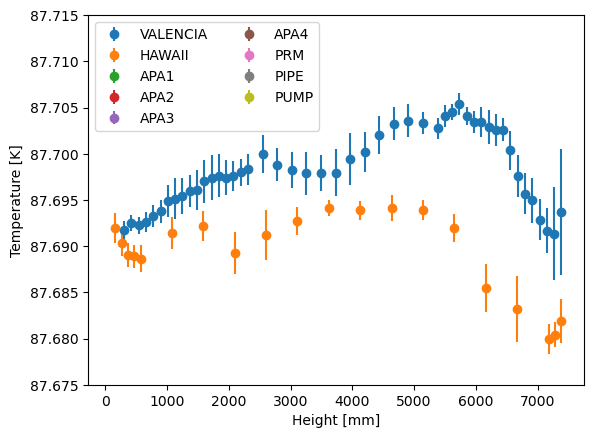

In [25]:
tgrad.makeProfiles(tini=datetime.datetime(2024, 12, 5, 8, 45, 0), tend=datetime.datetime(2024, 12, 5, 9, 0, 0))
hawai.makeProfiles(tini=datetime.datetime(2024, 12, 5, 8, 45, 0), tend=datetime.datetime(2024, 12, 5, 9, 0, 0))
apa.makeProfiles(tini=datetime.datetime(2024, 12, 5, 8, 45, 0), tend=datetime.datetime(2024, 12, 5, 9, 0, 0))
# apa.makeProfiles(tini=datetime.datetime(2024, 12, 2, 5, 45, 0), tend=datetime.datetime(2024, 12, 2, 6, 0, 0))
pipe.makeProfiles(tini=datetime.datetime(2024, 11, 27, 8, 45, 0), tend=datetime.datetime(2024, 11, 27, 9, 0, 0))
prm.makeProfiles(tini=datetime.datetime(2024, 11, 27, 8, 45, 0), tend=datetime.datetime(2024, 11, 27, 9, 0, 0))
pp.makeProfiles(tini=datetime.datetime(2024, 11, 27, 8, 45, 0), tend=datetime.datetime(2024, 11, 27, 9, 0, 0))
plt.errorbar(tgrad.profiles["Y"].values, tgrad.profiles["temp"].values, yerr=tgrad.profiles["err"].values, fmt='o', label="VALENCIA")
plt.errorbar(hawai.profiles["Y"].values, hawai.profiles["temp"].values, yerr=hawai.profiles["err"].values, fmt='o', label="HAWAII")
mask1 = apa.profiles["name"].str.contains("APA1", na=False) & ~apa.profiles["name"].str.contains("F", na=False)
mask2 = apa.profiles["name"].str.contains("APA2", na=False) & ~apa.profiles["name"].str.contains("F", na=False)
mask3 = apa.profiles["name"].str.contains("APA3", na=False) & ~apa.profiles["name"].str.contains("F", na=False)
mask4 = apa.profiles["name"].str.contains("APA4", na=False) & ~apa.profiles["name"].str.contains("F", na=False)

print(apa.profiles.loc[mask1, "temp"].values)
plt.errorbar(
    apa.profiles.loc[mask1, "Y"].values,
    apa.profiles.loc[mask1, "temp"].values,
    yerr=apa.profiles.loc[mask1, "err"].values,
    fmt='o',
    label="APA1"
)
plt.errorbar(
    apa.profiles.loc[mask2, "Y"].values,
    apa.profiles.loc[mask2, "temp"].values,
    yerr=apa.profiles.loc[mask2, "err"].values,
    fmt='o',
    label="APA2"
)
plt.errorbar(
    apa.profiles.loc[mask3, "Y"].values,
    apa.profiles.loc[mask3, "temp"].values,
    yerr=apa.profiles.loc[mask3, "err"].values,
    fmt='o',
    label="APA3"
)
plt.errorbar(
    apa.profiles.loc[mask4, "Y"].values,
    apa.profiles.loc[mask4, "temp"].values,
    yerr=apa.profiles.loc[mask4, "err"].values,
    fmt='o',
    label="APA4"
)
plt.errorbar(prm.profiles["Y"].values, prm.profiles["temp"].values, yerr=prm.profiles["err"].values, fmt='o', label="PRM")
plt.errorbar(pipe.profiles["Y"].values, pipe.profiles["temp"].values, yerr=pipe.profiles["err"].values, fmt='o', label="PIPE")
plt.errorbar(pp.profiles["Y"].values, pp.profiles["temp"].values, yerr=pp.profiles["err"].values, fmt='o', label="PUMP")
print(pp.profiles["temp"].values)
plt.ylim(87.675, 87.715)
plt.legend(ncol=2);
plt.xlabel("Height [mm]")
plt.ylabel("Temperature [K]")

In [14]:
import plotly.graph_objects as go

# Apply masks to filter data based on Y < 2000
tmask = tgrad.profiles["Y"] < 2000
hmask = hawai.profiles["Y"] < 2000
pmask = pipe.profiles["temp"] < 88
amask = apa.profiles["Y"] < 2000

# Create a 3D scatter plot with Plotly
fig = go.Figure()

# Plot the data for VALENCIA (tgrad)
fig.add_trace(go.Scatter3d(
    x=tgrad.profiles[tmask]["X"].values,
    y=tgrad.profiles[tmask]["Z"].values,
    z=tgrad.profiles[tmask]["Y"].values,
    mode='markers',
    marker=dict(
        size=5,
        color=tgrad.profiles[tmask]["temp"].values,  # Color by temperature
        colorscale='Viridis',  # Colormap
        colorbar=dict(title='Temperature [K]')  # Colorbar
    ),
    name='VALENCIA'
))

# Plot the data for HAWAII (hawai)
fig.add_trace(go.Scatter3d(
    x=hawai.profiles[hmask]["X"].values,
    y=hawai.profiles[hmask]["Z"].values,
    z=hawai.profiles[hmask]["Y"].values,
    mode='markers',
    marker=dict(
        size=5,
        color=hawai.profiles[hmask]["temp"].values,
        colorscale='Viridis',
        colorbar=dict(title='Temperature [K]')
    ),
    name='HAWAII'
))

# Plot the data for APA (apa)
fig.add_trace(go.Scatter3d(
    x=apa.profiles[amask]["X"].values,
    y=apa.profiles[amask]["Z"].values,
    z=apa.profiles[amask]["Y"].values,
    mode='markers',
    marker=dict(
        size=5,
        color=apa.profiles[amask]["temp"].values,
        colorscale='Viridis',
        colorbar=dict(title='Temperature [K]')
    ),
    name='APA'
))

# Plot the data for PIPE (pipe)
fig.add_trace(go.Scatter3d(
    x=pipe.profiles[pmask]["X"].values,
    y=pipe.profiles[pmask]["Z"].values,
    z=pipe.profiles[pmask]["Y"].values,
    mode='markers',
    marker=dict(
        size=5,
        color=pipe.profiles[pmask]["temp"].values,
        colorscale='Viridis',
        colorbar=dict(title='Temperature [K]')
    ),
    name='PIPE'
))

# Plot the data for PUMP (pp)
fig.add_trace(go.Scatter3d(
    x=pp.profiles["X"].values,
    y=pp.profiles["Z"].values,
    z=pp.profiles["Y"].values,
    mode='markers',
    marker=dict(
        size=5,
        color=pp.profiles["temp"].values,
        colorscale='Viridis',
        colorbar=dict(title='Temperature [K]')
    ),
    name='PUMP'
))

# Update layout for titles and axis labels
fig.update_layout(
    title="3D Scatter Plot of X, Z, Y with Temperature as Color",
    scene=dict(
        xaxis_title='X Coordinate [mm]',
        yaxis_title='Z Coordinate [mm]',
        zaxis_title='Y Coordinate [mm]'
    ),
    legend=dict(title="Legend", orientation="h")
)

# Show the interactive plot
fig.show()

# Check the 'pipe' profile data
print(hawai.profiles)


         X       Y       Z     name       temp       err
0   7855.0   643.0  6258.0   HAWAI1        NaN       NaN
1   7855.0   571.0  6258.0   HAWAI2  87.609401  0.001364
2   7855.0   470.0  6258.0   HAWAI3  87.609635  0.001181
3   7855.0   368.0  6258.0   HAWAI4  87.609810  0.001288
4   7855.0   267.0  6258.0   HAWAI5  87.611029  0.001322
5   7855.0   165.0  6258.0   HAWAI6  87.612685  0.001608
6   7855.0  3619.0  6258.0   HAWAI7  87.614860  0.000757
7   7855.0  3111.0  6258.0   HAWAI8  87.613461  0.001481
8   7855.0  2603.0  6258.0   HAWAI9  87.611941  0.002843
9   7855.0  2095.0  6258.0  HAWAI10  87.610019  0.002405
10  7855.0  1587.0  6258.0  HAWAI11  87.612874  0.001697
11  7855.0  1079.0  6258.0  HAWAI12  87.612108  0.001732
12  7855.0  6667.0  6258.0  HAWAI13  87.603915  0.003442
13  7855.0  6159.0  6258.0  HAWAI14  87.606228  0.002632
14  7855.0  5651.0  6258.0  HAWAI15  87.612714  0.001436
15  7855.0  5143.0  6258.0  HAWAI16  87.614660  0.001128
16  7855.0  4635.0  6258.0  HAW

[87.62009846 87.62401978]


Text(0, 0.5, 'Temperature [K]')

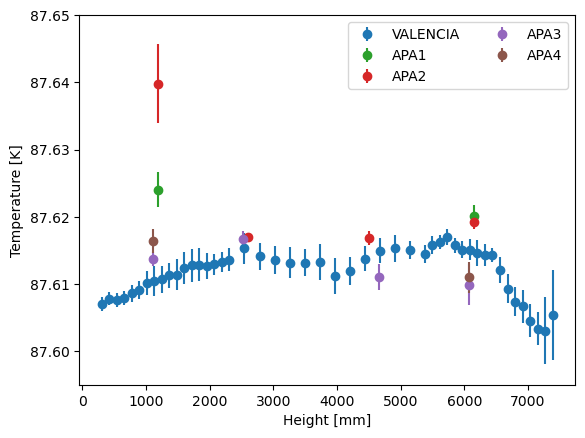

In [14]:
tgrad.makeProfiles(tini=datetime.datetime(2024, 12, 5, 8, 45, 0), tend=datetime.datetime(2024, 12, 5, 9, 0, 0))
hawai.makeProfiles(tini=datetime.datetime(2024, 12, 5, 8, 45, 0), tend=datetime.datetime(2024, 12, 5, 9, 0, 0))
apa.makeProfiles(tini=datetime.datetime(2024, 12, 5, 8, 45, 0), tend=datetime.datetime(2024, 12, 5, 9, 0, 0))
pipe.makeProfiles(tini=datetime.datetime(2024, 11, 27, 8, 45, 0), tend=datetime.datetime(2024, 11, 27, 9, 0, 0))
prm.makeProfiles(tini=datetime.datetime(2024, 11, 27, 8, 45, 0), tend=datetime.datetime(2024, 11, 27, 9, 0, 0))
pp.makeProfiles(tini=datetime.datetime(2024, 11, 27, 8, 45, 0), tend=datetime.datetime(2024, 11, 27, 9, 0, 0))
plt.errorbar(tgrad.profiles["Y"].values, tgrad.profiles["temp"].values, yerr=tgrad.profiles["err"].values, fmt='o', label="VALENCIA")
mask1 = apa.profiles["name"].str.contains("APA1", na=False) & ~apa.profiles["name"].str.contains("F", na=False)
mask2 = apa.profiles["name"].str.contains("APA2", na=False) & ~apa.profiles["name"].str.contains("F", na=False)
mask3 = apa.profiles["name"].str.contains("APA3", na=False) & ~apa.profiles["name"].str.contains("F", na=False)
mask4 = apa.profiles["name"].str.contains("APA4", na=False) & ~apa.profiles["name"].str.contains("F", na=False)

print(apa.profiles.loc[mask1, "temp"].values)
plt.errorbar(
    apa.profiles.loc[mask1, "Y"].values,
    apa.profiles.loc[mask1, "temp"].values,
    yerr=apa.profiles.loc[mask1, "err"].values,
    fmt='o',
    label="APA1",
    color="tab:green"
)
plt.errorbar(
    apa.profiles.loc[mask2, "Y"].values,
    apa.profiles.loc[mask2, "temp"].values,
    yerr=apa.profiles.loc[mask2, "err"].values,
    fmt='o',
    label="APA2",
    color="tab:red"
)
plt.errorbar(
    apa.profiles.loc[mask3, "Y"].values,
    apa.profiles.loc[mask3, "temp"].values,
    yerr=apa.profiles.loc[mask3, "err"].values,
    fmt='o',
    label="APA3",
    color="tab:purple"
)
plt.errorbar(
    apa.profiles.loc[mask4, "Y"].values,
    apa.profiles.loc[mask4, "temp"].values,
    yerr=apa.profiles.loc[mask4, "err"].values,
    fmt='o',
    label="APA4",
    color="tab:brown"
)
plt.ylim(87.595, 87.65)
plt.legend(ncol=2);
plt.xlabel("Height [mm]")
plt.ylabel("Temperature [K]")

[87.59998317 87.60010699]


Text(0, 0.5, 'Temperature [K]')

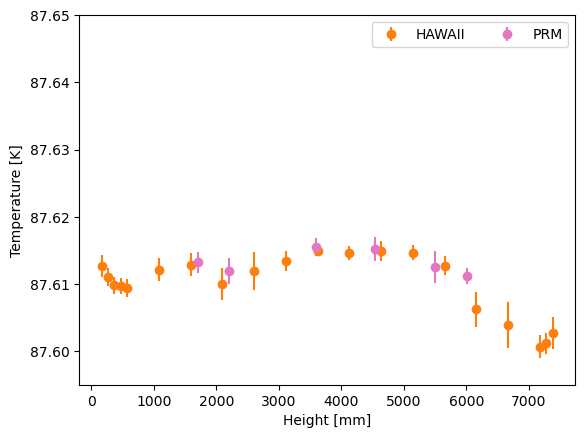

In [44]:
tgrad.makeProfiles(tini=datetime.datetime(2024, 12, 5, 8, 45, 0), tend=datetime.datetime(2024, 12, 5, 9, 0, 0))
hawai.makeProfiles(tini=datetime.datetime(2024, 12, 5, 8, 45, 0), tend=datetime.datetime(2024, 12, 5, 9, 0, 0))
apa.makeProfiles(tini=datetime.datetime(2024, 12, 5, 8, 45, 0), tend=datetime.datetime(2024, 12, 5, 9, 0, 0))
pipe.makeProfiles(tini=datetime.datetime(2024, 11, 27, 8, 45, 0), tend=datetime.datetime(2024, 11, 27, 9, 0, 0))
prm.makeProfiles(tini=datetime.datetime(2024, 11, 27, 8, 45, 0), tend=datetime.datetime(2024, 11, 27, 9, 0, 0))
pp.makeProfiles(tini=datetime.datetime(2024, 11, 27, 8, 45, 0), tend=datetime.datetime(2024, 11, 27, 9, 0, 0))
# plt.errorbar(tgrad.profiles["Y"].values, tgrad.profiles["temp"].values, yerr=tgrad.profiles["err"].values, fmt='o', label="VALENCIA")
plt.errorbar(hawai.profiles["Y"].values, hawai.profiles["temp"].values, yerr=hawai.profiles["err"].values, fmt='o', label="HAWAII", color="tab:orange")
mask1 = apa.profiles["name"].str.contains("APA1", na=False) & ~apa.profiles["name"].str.contains("F", na=False)
mask2 = apa.profiles["name"].str.contains("APA2", na=False) & ~apa.profiles["name"].str.contains("F", na=False)
mask3 = apa.profiles["name"].str.contains("APA3", na=False) & ~apa.profiles["name"].str.contains("F", na=False)
mask4 = apa.profiles["name"].str.contains("APA4", na=False) & ~apa.profiles["name"].str.contains("F", na=False)

# print(apa.profiles.loc[mask1, "temp"].values)
# plt.errorbar(
#     apa.profiles.loc[mask1, "Y"].values,
#     apa.profiles.loc[mask1, "temp"].values,
#     yerr=apa.profiles.loc[mask1, "err"].values,
#     fmt='o',
#     label="APA1"
# )
# plt.errorbar(
#     apa.profiles.loc[mask2, "Y"].values,
#     apa.profiles.loc[mask2, "temp"].values,
#     yerr=apa.profiles.loc[mask2, "err"].values,
#     fmt='o',
#     label="APA2"
# )
# plt.errorbar(
#     apa.profiles.loc[mask3, "Y"].values,
#     apa.profiles.loc[mask3, "temp"].values,
#     yerr=apa.profiles.loc[mask3, "err"].values,
#     fmt='o',
#     label="APA3"
# )
# plt.errorbar(
#     apa.profiles.loc[mask4, "Y"].values,
#     apa.profiles.loc[mask4, "temp"].values,
#     yerr=apa.profiles.loc[mask4, "err"].values,
#     fmt='o',
#     label="APA4"
# )
plt.errorbar(prm.profiles["Y"].values, prm.profiles["temp"].values + 0.005, yerr=prm.profiles["err"].values, fmt='o', label="PRM", color="tab:pink")
# plt.errorbar(pipe.profiles["Y"].values, pipe.profiles["temp"].values + 0.005, yerr=pipe.profiles["err"].values, fmt='o', label="PIPE")
# plt.errorbar(pp.profiles["Y"].values, pp.profiles["temp"].values + 0.005, yerr=pp.profiles["err"].values, fmt='o', label="PUMP")
print(pp.profiles["temp"].values)
plt.ylim(87.595, 87.65)
plt.legend(ncol=2);
plt.xlabel("Height [mm]")
plt.ylabel("Temperature [K]")

[87.62009846 87.62401978]


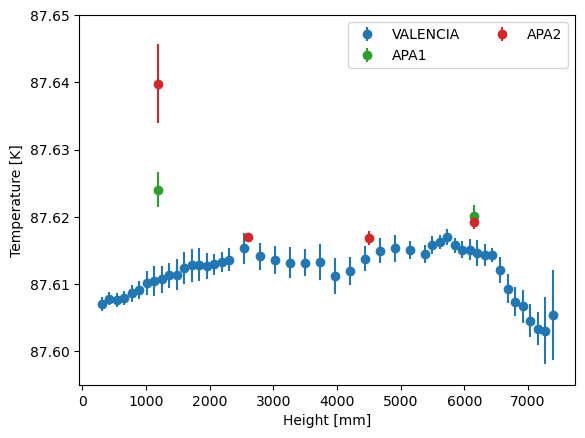

In [10]:
tgrad.makeProfiles(tini=datetime.datetime(2024, 12, 5, 8, 45, 0), tend=datetime.datetime(2024, 12, 5, 9, 0, 0))
hawai.makeProfiles(tini=datetime.datetime(2024, 12, 5, 8, 45, 0), tend=datetime.datetime(2024, 12, 5, 9, 0, 0))
apa.makeProfiles(tini=datetime.datetime(2024, 12, 5, 8, 45, 0), tend=datetime.datetime(2024, 12, 5, 9, 0, 0))
pipe.makeProfiles(tini=datetime.datetime(2024, 11, 27, 8, 45, 0), tend=datetime.datetime(2024, 11, 27, 9, 0, 0))
prm.makeProfiles(tini=datetime.datetime(2024, 11, 27, 8, 45, 0), tend=datetime.datetime(2024, 11, 27, 9, 0, 0))
pp.makeProfiles(tini=datetime.datetime(2024, 11, 27, 8, 45, 0), tend=datetime.datetime(2024, 11, 27, 9, 0, 0))
plt.errorbar(tgrad.profiles["Y"].values, tgrad.profiles["temp"].values, yerr=tgrad.profiles["err"].values, fmt='o', label="VALENCIA")
# plt.errorbar(hawai.profiles["Y"].values, hawai.profiles["temp"].values, yerr=hawai.profiles["err"].values, fmt='o', label="HAWAII")
mask1 = apa.profiles["name"].str.contains("APA1", na=False) & ~apa.profiles["name"].str.contains("F", na=False)
mask2 = apa.profiles["name"].str.contains("APA2", na=False) & ~apa.profiles["name"].str.contains("F", na=False)
mask3 = apa.profiles["name"].str.contains("APA3", na=False) & ~apa.profiles["name"].str.contains("F", na=False)
mask4 = apa.profiles["name"].str.contains("APA4", na=False) & ~apa.profiles["name"].str.contains("F", na=False)

print(apa.profiles.loc[mask1, "temp"].values)
plt.errorbar(
    apa.profiles.loc[mask1, "Y"].values,
    apa.profiles.loc[mask1, "temp"].values,
    yerr=apa.profiles.loc[mask1, "err"].values,
    fmt='o',
    label="APA1",
    color="tab:green"
)
plt.errorbar(
    apa.profiles.loc[mask2, "Y"].values,
    apa.profiles.loc[mask2, "temp"].values,
    yerr=apa.profiles.loc[mask2, "err"].values,
    fmt='o',
    label="APA2",
    color="tab:red"
)
# plt.errorbar(
#     apa.profiles.loc[mask3, "Y"].values,
#     apa.profiles.loc[mask3, "temp"].values,
#     yerr=apa.profiles.loc[mask3, "err"].values,
#     fmt='o',
#     label="APA3"
# )
# plt.errorbar(
#     apa.profiles.loc[mask4, "Y"].values,
#     apa.profiles.loc[mask4, "temp"].values,
#     yerr=apa.profiles.loc[mask4, "err"].values,
#     fmt='o',
#     label="APA4"
# )
mask5 = pipe.profiles["name"].str.contains("U", na=False)
# plt.errorbar(prm.profiles["Y"].values, prm.profiles["temp"].values + 0.005, yerr=prm.profiles["err"].values, fmt='o', label="PRM")
#plt.errorbar(pipe.profiles.loc[mask5, "Y"].values, pipe.profiles.loc[mask5, "temp"].values + 0.005, yerr=pipe.profiles.loc[mask5, "err"].values, fmt='o', label="PIPE", color="tab:grey")
# plt.errorbar(pp.profiles["Y"].values, pp.profiles["temp"].values + 0.005, yerr=pp.profiles["err"].values, fmt='o', label="PUMP")
plt.ylim(87.595, 87.65)
plt.legend(ncol=2);
plt.xlabel("Height [mm]")
plt.ylabel("Temperature [K]")
plt.savefig("/eos/user/j/jcapotor/DUNE-IFIC/Experiments/ProtoDUNE-HD/Operation/Plots/temp_homo_stab/normal_operation_saleve.pdf", format="pdf")

[87.62009846 87.62401978]


Text(0, 0.5, 'Temperature [K]')

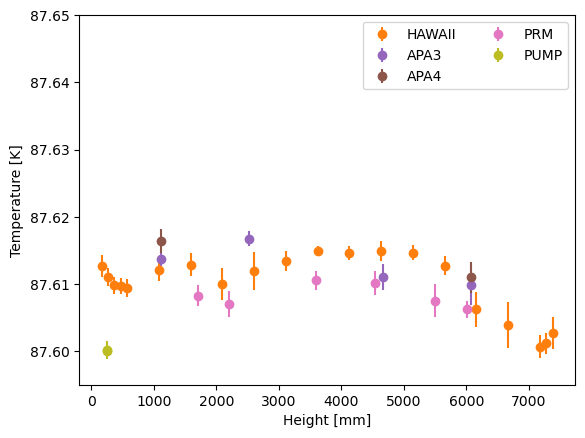

In [ ]:
tgrad.makeProfiles(tini=datetime.datetime(2024, 12, 5, 8, 45, 0), tend=datetime.datetime(2024, 12, 5, 9, 0, 0))
hawai.makeProfiles(tini=datetime.datetime(2024, 12, 5, 8, 45, 0), tend=datetime.datetime(2024, 12, 5, 9, 0, 0))
apa.makeProfiles(tini=datetime.datetime(2024, 12, 5, 8, 45, 0), tend=datetime.datetime(2024, 12, 5, 9, 0, 0))
pipe.makeProfiles(tini=datetime.datetime(2024, 11, 27, 8, 45, 0), tend=datetime.datetime(2024, 11, 27, 9, 0, 0))
prm.makeProfiles(tini=datetime.datetime(2024, 11, 27, 8, 45, 0), tend=datetime.datetime(2024, 11, 27, 9, 0, 0))
pp.makeProfiles(tini=datetime.datetime(2024, 11, 27, 8, 45, 0), tend=datetime.datetime(2024, 11, 27, 9, 0, 0))
#plt.errorbar(tgrad.profiles["Y"].values, tgrad.profiles["temp"].values, yerr=tgrad.profiles["err"].values, fmt='o', label="VALENCIA")
plt.errorbar(hawai.profiles["Y"].values, hawai.profiles["temp"].values, yerr=hawai.profiles["err"].values, fmt='o', label="HAWAII", color="tab:orange")
mask1 = apa.profiles["name"].str.contains("APA1", na=False) & ~apa.profiles["name"].str.contains("F", na=False)
mask2 = apa.profiles["name"].str.contains("APA2", na=False) & ~apa.profiles["name"].str.contains("F", na=False)
mask3 = apa.profiles["name"].str.contains("APA3", na=False) & ~apa.profiles["name"].str.contains("F", na=False)
mask4 = apa.profiles["name"].str.contains("APA4", na=False) & ~apa.profiles["name"].str.contains("F", na=False)

print(apa.profiles.loc[mask1, "temp"].values)
# plt.errorbar(
#     apa.profiles.loc[mask1, "Y"].values,
#     apa.profiles.loc[mask1, "temp"].values,
#     yerr=apa.profiles.loc[mask1, "err"].values,
#     fmt='o',
#     label="APA1"
# )
# plt.errorbar(
#     apa.profiles.loc[mask2, "Y"].values,
#     apa.profiles.loc[mask2, "temp"].values,
#     yerr=apa.profiles.loc[mask2, "err"].values,
#     fmt='o',
#     label="APA2"
# )
plt.errorbar(
    apa.profiles.loc[mask3, "Y"].values,
    apa.profiles.loc[mask3, "temp"].values,
    yerr=apa.profiles.loc[mask3, "err"].values,
    fmt='o',
    label="APA3",
    color="tab:purple"
)
plt.errorbar(
    apa.profiles.loc[mask4, "Y"].values,
    apa.profiles.loc[mask4, "temp"].values,
    yerr=apa.profiles.loc[mask4, "err"].values,
    fmt='o',
    label="APA4",
    color="tab:brown"
)
mask5 = pipe.profiles["name"].str.contains("M", na=False)
plt.errorbar(prm.profiles["Y"].values, prm.profiles["temp"].values, yerr=prm.profiles["err"].values, fmt='o', label="PRM", color="tab:pink")
#plt.errorbar(pipe.profiles.loc[mask5, "Y"].values, pipe.profiles.loc[mask5, "temp"].values + 0.005, yerr=pipe.profiles.loc[mask5, "err"].values, fmt='o', label="PIPE", color="tab:grey")
# plt.errorbar(pp.profiles["Y"].values, pp.profiles["temp"].values, yerr=pp.profiles["err"].values, fmt='o', label="PUMP", color="tab:olive")
plt.ylim(87.595, 87.65)
plt.legend(ncol=2);
plt.xlabel("Height [mm]")
plt.ylabel("Temperature [K]")
plt.savefig("/eos/user/j/jcapotor/DUNE-IFIC/Experiments/ProtoDUNE-HD/Operation/Plots/temp_homo_stab/normal_operation_jura.pdf", format="pdf")